# QASPER Scientific QA with Section Chunks

This notebook demonstrates the **QASPER dataset preparation pipeline** for MVT-RAG evaluation on long scientific documents.

QASPER (Dasigi et al. 2021, NAACL) contains NLP papers with full text, question-answer pairs, and annotated evidence paragraphs.
The pipeline converts raw QASPER rows into a structured format suitable for section-aware retrieval evaluation:
- Each example has an `input` (question + section layout summary) and `output` (gold answer + evidence chunk IDs)
- Metadata fields track split, paper ID, multihop flag, and evidence count

**Demo scale:** 10 examples from `mini_demo_data.json` (full run: 2000 examples from 888 papers)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — not pre-installed on Colab
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import json
import sys
from pathlib import Path
from loguru import logger
import matplotlib.pyplot as plt
import pandas as pd

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ae548-efficiency-at-a-cost-applying-the-margin/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
rows = load_data()
logger.info(f"Loaded {len(rows)} rows")

17:16:31|INFO   |Loaded 10 rows


## Config

All tunable parameters are defined here. Set to minimal values for the demo; scale up for a full run.

In [5]:
# Demo: process only N rows (set to None to process all loaded rows)
N_ROWS = None  # full run: None (process all 2000 examples)

## Helper Functions

`build_input` creates a JSON string encoding the question, paper ID, and a compact summary of the paper's section layout.
`build_output` creates a JSON string encoding the gold answer and which chunk IDs contain the evidence.

In [6]:
def build_input(row: dict) -> str:
    """Build the RAG retrieval input: question + section context summary."""
    sections_summary = "; ".join(
        f"[{s['normalized_name'].upper()}] {s['name']} ({len(s['chunks'])} chunks)"
        for s in row["sections"]
    )
    return json.dumps({
        "question": row["question"],
        "paper_id": row["paper_id"],
        "sections": sections_summary,
        "num_sections": row["num_sections"],
    })


def build_output(row: dict) -> str:
    """Build the output: gold answer + evidence location."""
    return json.dumps({
        "gold_answer": row["gold_answer"],
        "evidence_chunk_ids": row["evidence_chunk_ids"],
        "evidence_section_names": row["evidence_section_names"],
    })

## Processing

Iterate over each row and build the `input`/`output` pair plus metadata fields.
The result follows the `exp_sel_data_out` schema used across MVT-RAG experiments.

In [7]:
rows_to_process = rows[:N_ROWS] if N_ROWS else rows
logger.info(f"Processing {len(rows_to_process)} rows")

examples = []
for row in rows_to_process:
    inp = build_input(row)
    out = build_output(row)
    examples.append({
        "input": inp,
        "output": out,
        "metadata_fold": 0 if row["split"] == "train" else 1,
        "metadata_paper_id": row["paper_id"],
        "metadata_question_id": row["question_id"],
        "metadata_is_multihop": row["is_multihop"],
        "metadata_num_sections": row["num_sections"],
        "metadata_split": row["split"],
        "metadata_evidence_count": len(row["evidence_chunk_ids"]),
        "metadata_task_type": "rag_qa",
    })

result = {
    "metadata": {
        "source": "allenai/qasper",
        "description": "QASPER section-annotated chunks for MVT-RAG evaluation",
        "total_examples": len(examples),
        "multihop_count": sum(1 for e in examples if e["metadata_is_multihop"]),
    },
    "datasets": [
        {
            "dataset": "qasper",
            "examples": examples,
        }
    ],
}

logger.info(f"Built {len(examples)} examples ({result['metadata']['multihop_count']} multihop)")

17:16:31|INFO   |Processing 10 rows


17:16:31|INFO   |Built 10 examples (3 multihop)


## Results

Inspect a sample example and visualize the dataset composition.

Total examples: 10
Multihop: 3 | Single-hop: 7
Train: 7 | Validation: 3

  paper_id      split  is_multihop  num_sections  evidence_count
1902.09314      train        False            13               1
1904.07342      train        False             5               1
1703.04617      train        False             7               1
1911.09419      train        False            21               1
1701.03051      train        False            12               3
1910.05154      train         True             6               3
1909.06200 validation         True            15               4
1909.09986      train         True            20               2
1907.09369 validation        False             8               1
1706.09673 validation        False             9               2

=== Sample Input ===
{
  "question": "How is their model different from BERT?",
  "paper_id": "1902.09314",
  "sections": "[INTRODUCTION] Introduction (6 chunks); [RELATED_WORK] Related Work (3 chunks); [METHODS

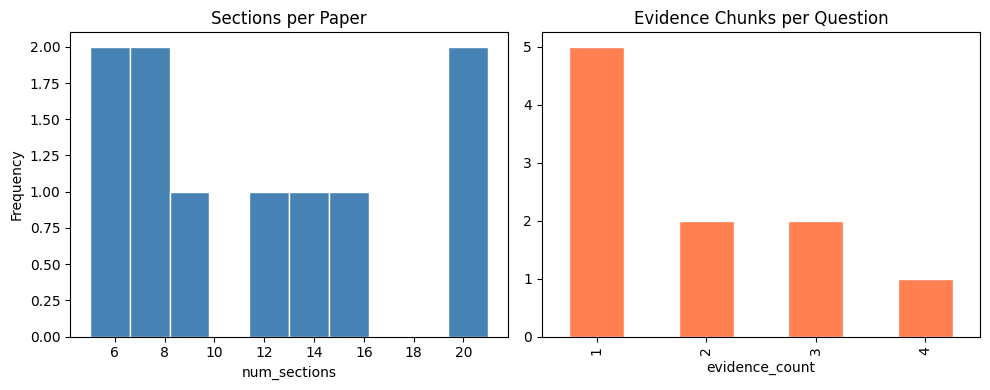

In [8]:
# Print summary table
df = pd.DataFrame([
    {
        "paper_id": e["metadata_paper_id"],
        "split": e["metadata_split"],
        "is_multihop": e["metadata_is_multihop"],
        "num_sections": e["metadata_num_sections"],
        "evidence_count": e["metadata_evidence_count"],
    }
    for e in examples
])
print(f"Total examples: {len(examples)}")
print(f"Multihop: {df['is_multihop'].sum()} | Single-hop: {(~df['is_multihop']).sum()}")
print(f"Train: {(df['split']=='train').sum()} | Validation: {(df['split']=='validation').sum()}")
print()
print(df.to_string(index=False))

# Sample example
print("\n=== Sample Input ===")
print(json.dumps(json.loads(examples[0]["input"]), indent=2)[:500])
print("\n=== Sample Output ===")
print(json.dumps(json.loads(examples[0]["output"]), indent=2)[:400])

# Plot: sections per paper
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["num_sections"].plot.hist(ax=axes[0], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title("Sections per Paper")
axes[0].set_xlabel("num_sections")

df["evidence_count"].value_counts().sort_index().plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Evidence Chunks per Question")
axes[1].set_xlabel("evidence_count")
plt.tight_layout()
plt.show()